## Main Objectives

Identify the behavioural, demographic, and subscription-level signals that precede customer churn at NovaDash, and quantify the revenue impact to inform a targeted retention strategy.

### Key Analytical Questions to Answer
#### Who is churning and why?

- Where is churn concentrated?
- Why are they churning?
- When do they churn?
- What does a churned customer look like vs a retained one?
- What's the revenue impact?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("novadash_master.csv", low_memory = False)
df_accounts = pd.read_csv("novadash_accounts.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147896 entries, 0 to 147895
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   account_id                   147896 non-null  str    
 1   account_name                 147896 non-null  str    
 2   industry                     147896 non-null  str    
 3   country                      147896 non-null  str    
 4   signup_date                  147896 non-null  str    
 5   referral_source              147896 non-null  str    
 6   plan_tier                    147896 non-null  str    
 7   seats                        147896 non-null  int64  
 8   is_trial                     147896 non-null  bool   
 9   churn_flag                   147896 non-null  bool   
 10  subscription_id              147896 non-null  str    
 11  start_date                   147896 non-null  str    
 12  end_date                     14600 non-null   str    
 13  mrr_amount

In [4]:
df_accounts.info()
df_accounts.head()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   account_id                500 non-null    str    
 1   industry                  500 non-null    str    
 2   country                   500 non-null    str    
 3   plan_tier                 500 non-null    str    
 4   referral_source           500 non-null    str    
 5   churn_flag                500 non-null    bool   
 6   is_trial                  500 non-null    bool   
 7   signup_date               500 non-null    str    
 8   total_subscriptions       500 non-null    int64  
 9   avg_mrr                   500 non-null    float64
 10  ever_upgraded             500 non-null    bool   
 11  ever_downgraded           500 non-null    bool   
 12  first_subscription_date   500 non-null    str    
 13  total_usage               500 non-null    int64  
 14  unique_features_used 

,account_id,industry,country,plan_tier,referral_source,churn_flag,is_trial,signup_date,total_subscriptions,avg_mrr,...,total_tickets,avg_satisfaction,worst_satisfaction,total_escalations,avg_resolution_hours,reason_code,churn_date,is_reactivation,preceding_downgrade_flag,preceding_upgrade_flag
0,A-00bed1,Cybersecurity,US,Basic,ads,False,True,2023-11-14,10,3152.098039,...,4,4.0,4.0,0.0,31.750000,unknown,2024-01-03,False,False,False
1,A-00cac8,HealthTech,AU,Enterprise,organic,False,True,2023-09-15,9,1466.500000,...,2,NaN,NaN,0.0,33.000000,NaN,NaN,NaN,NaN,NaN
2,A-0158bb,FinTech,DE,Basic,partner,False,False,2024-05-22,6,803.166667,...,1,3.0,3.0,0.0,32.000000,NaN,NaN,NaN,NaN,NaN
3,A-016043,EdTech,CA,Basic,organic,False,True,2024-07-31,11,1592.914894,...,3,4.0,4.0,0.0,30.333333,competitor,2024-08-11,False,False,False
4,A-019782,DevTools,FR,Enterprise,event,False,False,2023-04-19,9,933.763636,...,2,3.0,3.0,0.0,10.000000,NaN,NaN,NaN,NaN,NaN


In [5]:
# Converting dates from string to datetime

df['signup_date'] = pd.to_datetime(df['signup_date'])
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
df['churn_date'] = pd.to_datetime(df['churn_date'])
df['usage_date'] = pd.to_datetime(df['usage_date'])
df_accounts['signup_date'] = pd.to_datetime(df_accounts['signup_date'])
df_accounts['first_subscription_date'] = pd.to_datetime(df_accounts['first_subscription_date'])
df_accounts['churn_date'] = pd.to_datetime(df_accounts['churn_date'])

In [6]:
# Overall churn rate

total_churned = df_accounts['churn_flag'].sum()
total_accounts = len(df_accounts)
churn_rate = total_churned / total_accounts * 100
print(f"Overall Churn Rate: {churn_rate}% - {total_churned} out of {total_accounts} customers.")

Overall Churn Rate: 22.0% - 110 out of 500 customers.


In [7]:
# Revenue lost

total_revenue = df_accounts['avg_mrr'].sum()
revenue_lost = df_accounts[df_accounts['churn_flag']==True]['avg_mrr'].sum()
revenue_lost_pct = (revenue_lost / total_revenue * 100).round(1)
print(f"{revenue_lost_pct}% of the revenue is lost, that is ${revenue_lost:.2f} out of ${total_revenue:.2f}.")

20.3% of the revenue is lost, that is $230079.35 out of $1132614.21.


### Overall Churn Rate

**22% of NovaDash accounts have churned, representing 20.3% of total monthly recurring revenue.**

This is significantly higher than typical B2B SaaS benchmarks of 5-7%,
indicating a retention problem that requires immediate attention.

In [8]:
# Churn rate by industry

churn_by_industry = df_accounts.groupby(['industry'])['churn_flag'] \
    .agg(['sum', 'count'])
churn_by_industry.columns = ['churned','total']
churn_by_industry['industry_churn_pct'] = (churn_by_industry['churned']/churn_by_industry['total']*100).round(1)
churn_by_industry = churn_by_industry.sort_values('industry_churn_pct', ascending=False)
churn_by_industry

,churned,total,industry_churn_pct
industry,,,
DevTools,35,113,31.0
FinTech,25,112,22.3
HealthTech,21,96,21.9
EdTech,13,79,16.5
Cybersecurity,16,100,16.0


In [9]:
# Churn rate by plan tier

churn_by_tier = df_accounts.groupby(['plan_tier'])['churn_flag'] \
    .agg(['sum', 'count'])
churn_by_tier.columns = ['churned','total']
churn_by_tier['tier_churn_pct'] = (churn_by_tier['churned']/churn_by_tier['total']*100).round(1)
churn_by_tier = churn_by_tier.sort_values('tier_churn_pct', ascending=False)
churn_by_tier

,churned,total,tier_churn_pct
plan_tier,,,
Enterprise,34,154,22.1
Basic,37,168,22.0
Pro,39,178,21.9


In [10]:
# Churn rate by referral source

churn_by_referral = df_accounts.groupby(['referral_source'])['churn_flag'] \
    .agg(['sum', 'count'])
churn_by_referral.columns = ['churned','total']
churn_by_referral['referral_churn_pct'] = (churn_by_referral['churned']/churn_by_referral['total']*100).round(1)
churn_by_referral = churn_by_referral.sort_values('referral_churn_pct', ascending=False)
churn_by_referral

,churned,total,referral_churn_pct
referral_source,,,
event,29,96,30.2
other,25,103,24.3
ads,23,98,23.5
organic,20,114,17.5
partner,13,89,14.6


In [11]:
# Heatmap: Churn rate by Industry & Referral Source

heatmap_data = df_accounts.groupby(['industry', 'referral_source']).agg(
    total=('account_id', 'count'),
    churned=('churn_flag', 'sum')
).assign(churn_rate=lambda x: (x['churned']/x['total']*100).round(1))

heatmap_data

total  churned  churn_rate
industry      referral_source                            
Cybersecurity ads                 17        2        11.8
              event               22        5        22.7
              organic             21        3        14.3
              other               20        5        25.0
              partner             20        1         5.0
DevTools      ads                 26       10        38.5
              event               23       10        43.5
              organic             24        6        25.0
              other               24        7        29.2
              partner             16        2        12.5
EdTech        ads                 15        0         0.0
              event                9        3        33.3
              organic             18        4        22.2
              other               17        4        23.5
              partner             20        2        10.0
FinTech       ads                 22        7        31.8
              event               26        6        23.1
              organic             20        3        15.0
              other               25        6        24.0
              partner             19        3        15.8
HealthTech    ads                 18        4        22.2
              event               16        5        31.2
              organic             31        4        12.9
              other               17        3        17.6
              partner             14        5        35.7

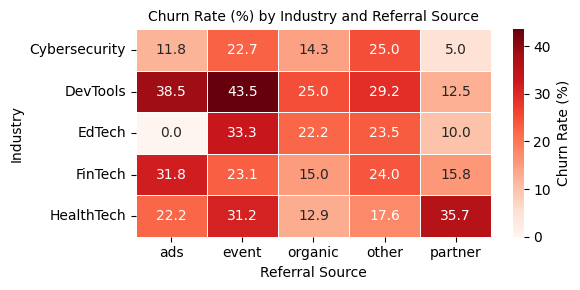

In [12]:
# Pivot for heatmap format
heatmap_pivot = heatmap_data['churn_rate'].unstack()

plt.figure(figsize=(6, 3))
sns.heatmap(heatmap_pivot, 
            annot=True, 
            fmt='.1f',
            cmap='Reds',
            linewidths=.5,
            cbar_kws={'label': 'Churn Rate (%)'})

plt.title('Churn Rate (%) by Industry and Referral Source', fontsize=10)
plt.xlabel('Referral Source')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

### Where is Churn Concentrated?

**By Industry:** DevTools has the highest churn rate at 31%, nearly double Cybersecurity (16%) and EdTech (16.5%). This suggests NovaDash's product may be less sticky for DevTools use cases.

**By Plan Tier:** Churn is evenly distributed across Basic (22%), Pro (21.9%), and Enterprise (22.1%). Plan tier is not a meaningful predictor of churn.

**By Referral Source:** Event-driven signups churn at the highest rate (30.2%), suggesting these customers may not incentive-driven rather than genuinely motivated. Organic and partner referrals show the lowest churn (17.5% and 14.6%), consistent with higher-intent acquisition channels.

In [13]:
# Why are they churning?
# By reason code

churn_reasons = df_accounts[df_accounts['churn_flag']==True] \
    .groupby('reason_code')['account_id'].count().reset_index()
churn_reasons.columns = ['reason_code','count']
churn_reasons['pct'] = (churn_reasons['count']/churn_reasons['count'].sum() * 100).round(1)
churn_reasons = churn_reasons.sort_values('pct', ascending=False)
churn_reasons.loc[len(churn_reasons)] = ['Total', churn_reasons['count'].sum(), \
                                         churn_reasons['pct'].sum().round()]
churn_reasons.reset_index(drop=True)

,reason_code,count,pct
0,budget,16,21.3
1,features,16,21.3
2,support,16,21.3
3,pricing,11,14.7
4,competitor,9,12.0
5,unknown,7,9.3
6,Total,75,100.0


In [14]:
industry_reasons = df_accounts[df_accounts['churn_flag']==True] \
    .groupby(['industry','reason_code'])['account_id'].count().reset_index()
industry_reasons.columns = ['industry','reason_code','count']
industry_reasons['pct'] = (industry_reasons['count']/industry_reasons.groupby('industry')['count'] \
    .transform('sum') * 100).round(1)
industry_reasons = industry_reasons.sort_values(['industry','count'], ascending=[True, False]).reset_index(drop=True)
industry_reasons

,industry,reason_code,count,pct
0,Cybersecurity,support,3,27.3
1,Cybersecurity,budget,2,18.2
2,Cybersecurity,features,2,18.2
3,Cybersecurity,pricing,2,18.2
4,Cybersecurity,unknown,2,18.2
5,DevTools,features,7,25.0
6,DevTools,support,6,21.4
7,DevTools,pricing,5,17.9
8,DevTools,budget,4,14.3
9,DevTools,competitor,4,14.3


### Why Are They Churning?

Of 110 churned accounts, **only 75 provided a reason code (68%)**. The remaining 35 accounts left without recorded feedback, a signal worth investigating.

Among accounts with a reason code, **budget, features, and support** concerns each account for 21.3% of churn, making them the three leading drivers. Pricing (14.7%) and competitive loss (12%) follow closely. This signals a product experience issue as a key churn driver.

**Note:** Sample size is limited to 75 accounts. Findings are directionally indicative, but should be interpreted with caution. Industry-level breakdown was explored but subgroup sizes (1-7 accounts per cell) are too small to draw reliable conclusions.

In [15]:
# Dropout window analysis

df_accounts['tenure_days'] = (df_accounts['churn_date']-df_accounts['signup_date']).dt.days
df_accounts[df_accounts['churn_flag']==True]['tenure_days'].describe()

count     75.000000
mean     177.773333
std      169.002365
min        2.000000
25%       40.500000
50%      104.000000
75%      280.500000
max      583.000000
Name: tenure_days, dtype: float64

In [16]:
# Categorizing the tenure length into 5 groups

bins = [0, 90, 180, 365, float('inf')]
labels = ['0-90 days', '91-180 days', '181-365 days', '365+ days']

df_accounts['tenure_bucket'] = pd.cut(df_accounts['tenure_days'],bins=bins, labels=labels)

dropout = df_accounts[df_accounts['churn_flag']==True]['tenure_bucket'] \
            .value_counts().sort_index()
dropout_pct = (dropout / dropout.sum() * 100).round(1)

pd.DataFrame({'count': dropout, 'pct': dropout_pct})

,count,pct
tenure_bucket,,
0-90 days,35,46.7
91-180 days,11,14.7
181-365 days,16,21.3
365+ days,13,17.3


### When Are They Churning? - Dropout Window

**The highest churn risk occurs within the first 90 days.**

- 18.7% of churned accounts left within the first 30 days.
- 28% churned between 31-90 days, the highest-risk window.
- Combined, 46.7% of all churn occurs within the first 3 months.

**This points to an onboarding problem** rather than long-term dissatisfaction. Customers who survive past 90 days distribute more evenly across later periods, suggesting they find sufficient value to stay longer once past the initial adoption phase.

In [17]:
# Behavioural Comparison: Churned vs Retained (on account level)

behaviour = df_accounts.groupby('churn_flag')[['total_usage', 'unique_features_used',
                                               'total_errors', 'total_tickets',
                                               'avg_resolution_hours',
                                               'avg_satisfaction', 'total_escalations',
                                               'ever_upgraded', 'ever_downgraded']].mean().round(2)
behaviour

,total_usage,unique_features_used,total_errors,total_tickets,avg_resolution_hours,avg_satisfaction,total_escalations,ever_upgraded,ever_downgraded
churn_flag,,,,,,,,,
False,2944.18,27.41,170.37,4.02,36.45,3.95,0.0,0.62,0.36
True,3000.85,28.34,164.78,3.93,35.49,4.00,0.0,0.58,0.34


### Behavioural Comparison - Churned vs Retained

**Account-level** averages show no meaningful difference between churned and retained customers across feature usage, error rates, support tickets, resolution hours, satisfaction scores, and upgrade/downgrade history.

**However, averaging across all accounts may obscure individual patterns.** Time-series analysis on granular usage data is required to detect behavioural signals that precede churn, explored in the dropout window analysis below.

In [18]:
# Pre-churn behaviour: Downgrade & Upgrade Flags

churned = df_accounts[df_accounts['churn_flag']==True]

pre_churn = pd.DataFrame({
    'count': [churned['preceding_downgrade_flag'].sum(),
              churned['preceding_upgrade_flag'].sum()],
    'total': [churned['preceding_downgrade_flag'].count(),
              churned['preceding_upgrade_flag'].count()]
}, index=['preceding_downgrade', 'preceding_upgrade'])

pre_churn['pct'] = (pre_churn['count']/pre_churn['total']*100).round(1)
pre_churn

,count,total,pct
preceding_downgrade,9,75,12.0
preceding_upgrade,16,75,21.3


In [19]:
pre_churn_tenure = df_accounts[
    (df_accounts['churn_flag']==True) & 
    ((df_accounts['preceding_upgrade_flag']==True) | 
    (df_accounts['preceding_downgrade_flag']==True))
].groupby('tenure_bucket')[['preceding_upgrade_flag', 'preceding_downgrade_flag']].sum()

pre_churn_tenure

,preceding_upgrade_flag,preceding_downgrade_flag
tenure_bucket,,
0-90 days,9,2
91-180 days,4,1
181-365 days,2,2
365+ days,1,4


In [20]:
df_accounts[((df_accounts['preceding_downgrade_flag']==True) |
            (df_accounts['preceding_upgrade_flag']==True)) & 
            (df_accounts['churn_flag']==True) &
            (df_accounts['tenure_bucket']=='0-90 days')] \
            .groupby(['preceding_downgrade_flag','preceding_upgrade_flag']) \
            ['reason_code'].value_counts()

preceding_downgrade_flag  preceding_upgrade_flag  reason_code
False                     True                    unknown        3
                                                  features       2
                                                  pricing        1
                                                  competitor     1
                                                  budget         1
True                      False                   competitor     1
                          True                    budget         1
Name: count, dtype: int64

### Why Are They Churning?
### Pre-churn Behaviour - Subscription Changes

**33% of churned accounts made a subscription change in the 90 days preceding churn.**

- **21.3% upgraded** before churning - suggesting customers attempted to resolve dissatisfaction by moving to a higher tier, but ultimately found it insufficient. This points to a product-fit problem that pricing alone cannot address.

- **12% downgraded** before churning - a classic signal of disengagement and cost-cutting ahead of full exit.

- Among early-stage accounts (0–90 days) that upgraded before churning, 
33% left no reason code — the highest data gap in any segment examined. 
These customers paid more and still left within 90 days, yet NovaDash 
has no record of why. **Capturing exit feedback from this segment specifically 
should be a priority.**

**Implication:** Subscription changes - particularly **upgrades in the early-cycle** of an account lifecycle, should be monitored as early warning signals for churn risk. A proactive outreach triggered by an upgrade event in the first 90 days could intercept at-risk accounts before they reach the point of cancellation.

In [21]:
# Pre-churn Behaviour: Reactivation Analysis

reactivation = df_accounts[df_accounts['is_reactivation']==True]['churn_flag'].value_counts().reset_index()
reactivation.columns = ['churned','count']
reactivation['pct'] = (reactivation['count']/reactivation['count'].sum() * 100).round(1)
reactivation

,churned,count,pct
0,False,23,88.5
1,True,3,11.5


### Pre-churn Behaviour - Reactivation Analysis

Of 26 reactivated accounts (customers who previously churned and returned), **88.5% are retained, only 3 users (11.5%) churned again.**

This suggests that **win-back efforts are effective at NovaDash**. Customers who return after churning tend to stay, indicating that re-engagement campaigns targeting recently churned accounts may be a viable retention strategy.

**Note:** Sample size is limited to 26 reactivated accounts. Findings are directionally encouraging but should be interpreted with caution.

In [22]:
# Pre-churn Behaviour: Usage Trajectory

churned_df = df[df['churn_flag']==True].copy()
churned_df['days_before_churn'] = (churned_df['churn_date'] - churned_df['usage_date']).dt.days
churned_df = churned_df[churned_df['days_before_churn'] >= 0]

# grouping usage events into time windows before churn
# to calculate average usage count per window
# to see if engagement drops as churn approaches

bins = [0,30,60,90,180, float('inf')]
labels = ['0-30 days','31-60 days','61-90 days','91-180 days','180+ days']
churned_df['days_before_churn'] = pd.cut(churned_df['days_before_churn'], bins=bins, labels=labels)

usage_trajectory = churned_df.groupby('days_before_churn')['usage_count'].mean().round(2)
usage_trajectory

days_before_churn
0-30 days       9.96
31-60 days      9.62
61-90 days     10.03
91-180 days     9.73
180+ days       9.96
Name: usage_count, dtype: float64

### Pre-Churn Behaviour — Feature Usage Trajectory

**Average feature usage remains flat across all time windows leading up to churn** 
(ranging from 9.62 to 10.03), with no observable decline as churn date approaches.

This **pattern is consistent with B2B SaaS behaviour**. Unlike consumer products 
where disengagement typically precedes cancellation, enterprise software tends 
to be used actively until a deliberate business decision is made to cancel. 
At NovaDash, churn is likely driven by budget cycles, procurement reviews, or 
unresolved product requirements rather than declining day-to-day usage.

Combined with earlier findings showing no meaningful difference in support 
tickets, satisfaction scores, or error rates between churned and retained 
accounts, this confirms that churn at NovaDash cannot be reliably detected 
through behavioural signals alone. This **reinforces the importance of proactive 
outreach during the critical 0–90 day onboarding window, and structured 
check-ins at contract renewal periods** when cancellation decisions are most likely made.

In [23]:
# Revenue impact by industry

churn = df_accounts[df_accounts['churn_flag']==True].groupby('industry')['account_id'].count()
total = df_accounts.groupby('industry')['avg_mrr'].sum().round(2)
lost = df_accounts[df_accounts['churn_flag']==True].groupby('industry')['avg_mrr'].sum().round(2)

revenue_industry = pd.DataFrame({'total_churn': churn, 'total_mrr': total, 'mrr_lost': lost})
revenue_industry['pct_lost'] = (revenue_industry['mrr_lost'] / revenue_industry['total_mrr'] * 100).round(1)
revenue_industry = revenue_industry.sort_values('mrr_lost', ascending=False)
revenue_industry['mrr_lost_per_churn'] = (revenue_industry['mrr_lost'] / revenue_industry['total_churn']).round(2)
revenue_industry

,total_churn,total_mrr,mrr_lost,pct_lost,mrr_lost_per_churn
industry,,,,,
DevTools,35,224833.51,60617.53,27.0,1731.93
FinTech,25,268859.97,52769.03,19.6,2110.76
HealthTech,21,198224.79,46973.74,23.7,2236.84
Cybersecurity,16,233873.00,41034.37,17.5,2564.65
EdTech,13,206822.94,28684.68,13.9,2206.51


In [24]:
# Revenue impact by tier

total = df_accounts.groupby('plan_tier')['avg_mrr'].sum().round(2)
lost = df_accounts[df_accounts['churn_flag']==True].groupby('plan_tier')['avg_mrr'].sum().round(2)

revenue_plan = pd.DataFrame({'total_mrr': total, 'revenue_lost': lost})
revenue_plan['pct_lost'] = (revenue_plan['revenue_lost'] / revenue_plan['total_mrr'] * 100).round(1)
revenue_plan = revenue_plan.sort_values('revenue_lost', ascending=False)
revenue_plan

,total_mrr,revenue_lost,pct_lost
plan_tier,,,
Pro,402971.05,81711.94,20.3
Basic,386964.90,81067.85,20.9
Enterprise,342678.26,67299.56,19.6


In [25]:
# Revenue impact by tenure bucket

total = df_accounts.groupby('tenure_bucket')['avg_mrr'].sum().round(2)
lost = df_accounts[df_accounts['churn_flag']==True].groupby('tenure_bucket')['avg_mrr'].sum().round(2)

revenue_plan = pd.DataFrame({'total_mrr': total, 'revenue_lost': lost})
revenue_plan['pct_lost'] = (revenue_plan['revenue_lost'] / revenue_plan['total_mrr'] * 100).round(1)
revenue_plan = revenue_plan.sort_values('revenue_lost', ascending=False)
revenue_plan

,total_mrr,revenue_lost,pct_lost
tenure_bucket,,,
0-90 days,435169.56,83649.70,19.2
91-180 days,159462.07,31510.71,19.8
181-365 days,144261.17,29070.88,20.2
365+ days,57884.45,20909.89,36.1


## Revenue Impact

**Overall:** NovaDash has **lost USD 230K in MRR** - equivalent to **USD 2.76M lost per year**, representing 20.3% of total recurring revenue.

**By Industry:** DevTools accounts for the largest absolute revenue loss (USD 61K - 27% of its total MRR), compounded by having the highest churn rate at 31%. Cybersecurity loses the most per churned account at USD 2.6K - nearly 48% more than DevTools (USD 1,732) - indicating that **while DevTools is a volume problem, Cybersecurity is a value problem**. EdTech has the lowest revenue loss in both absolute (USD 29K) and percentage terms (13.9%).

**By Plan Tier:** Revenue loss is evenly distributed across Basic (20.9%), Pro (20.3%), and Enterprise (19.6%) - plan tier is not a meaningful predictor of revenue risk.

**By Tenure:** The 0–90 day window represents the largest absolute revenue loss 
(USD 49.5K), consistent with it being the highest churn count period. Accounts churning after 365+ days show the highest loss rate (36.1%) but the smallest absolute loss (USD 20.9K), suggesting that **long-tenure accounts individually contribute more MRR on average, making each departure disproportionately costly**.



## Recommendations

The analysis suggests that churn at NovaDash is driven by **a combination of acquisition quality, early-stage activation challenges, product experience gaps, and high-value account retention risks**. The following recommendations are organised across the customer lifecycle to address churn at multiple stages.

### 1. Acquire the Right Customers
#### Optimise acquisition quality and expectation alignment

Event-acquired customers exhibit significantly higher churn rates than partner and organic channels, particularly within the DevTools segment. NovaDash should reassess acquisition channel effectiveness using retention quality rather than signup volume alone. This may include refining event targeting, introducing lightweight qualification criteria, and prioritising channels associated with stronger long-term retention.

### 2. Accelerate Early Value Realisation
#### Strengthen onboarding and activation during the first 90 days

Nearly half of all churn occurs within the first 90 days, despite churned accounts remaining actively engaged before cancellation. This suggests that usage alone may not translate into meaningful product activation. NovaDash should implement a structured onboarding programme focused on accelerating time-to-value through guided onboarding, proactive lifecycle check-ins, and clearer activation milestones.

#### Investigate early upgrade-to-churn behaviour

A meaningful share of early-stage churned accounts upgraded their plans before cancelling, suggesting that some customers may have been attempting to resolve unmet needs before exiting. NovaDash should audit upgrade journeys within the first 90 days and introduce proactive outreach for accounts exhibiting rapid plan changes.

### 3. Improve Product and Support Experience
#### Investigate recurring pain points within DevTools accounts

DevTools customers exhibit the highest churn rate and frequently cite feature limitations and support quality as churn drivers. NovaDash should conduct targeted qualitative research with at-risk and churned accounts to identify recurring product and operational friction points specific to this segment.

### 4. Protect High-Value Customer Relationships
#### Introduce high-touch retention support for strategic accounts

Long-tenure and Cybersecurity accounts generate disproportionately high revenue loss per churn event, making each departure economically significant despite lower churn frequency. NovaDash should introduce a dedicated Customer Success programme for high-value accounts, including quarterly business reviews, early renewal outreach, and priority support pathways.

### 5. Learn From and Re-engage Churned Customers
#### Strengthen post-churn feedback and recovery processes

A significant share of churned accounts exit without providing feedback, limiting visibility into underlying churn drivers. NovaDash should implement a structured exit feedback process and formalise targeted win-back campaigns for recently churned customers. Early reactivation data suggests that returning customers may retain successfully once re-engaged.

In [26]:
df_accounts.to_csv('novadash_tableau.csv', index=False)